<a href="https://colab.research.google.com/github/Fauzi455/PCVK26_12_M-Fauzi-R/blob/main/P2_Tugas%20D1_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#D1. Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya

1. Membuat koneksi antara Colab dengan Google Drive agar bisa
mengakses file di dalamnya.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
#mengakses gambar dengan fungsi upload file

from google.colab import files
uploaded = files.upload()

Saving KTP TUHAN.jpeg to KTP TUHAN.jpeg


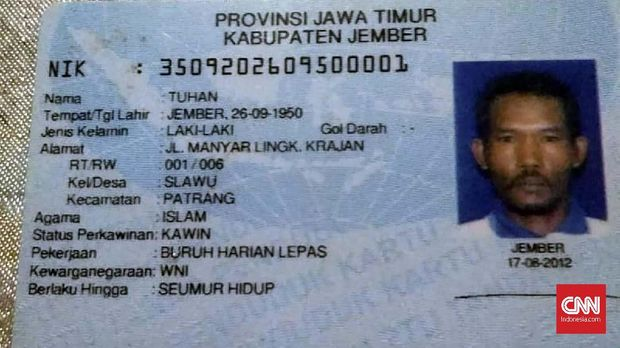

Resolusi gambar:  620  x  348


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTP TUHAN.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

2. Menampilkan Gambar

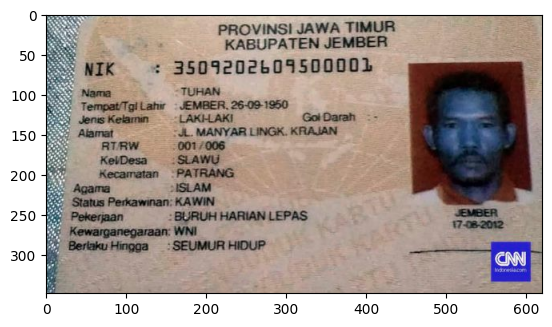

In [5]:
img = cv.imread('KTP TUHAN.jpeg')
plt.imshow(img)

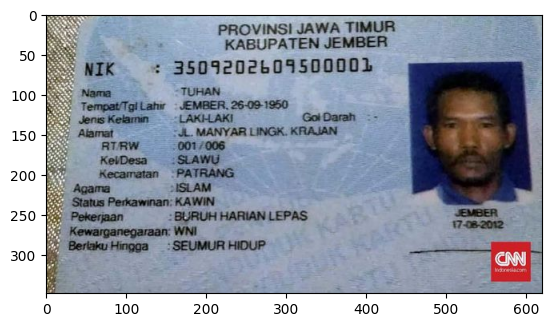

In [6]:
img = cv.imread('KTP TUHAN.jpeg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) #konversi channel BGR -> RGB
plt.imshow(img2)

3. Menampilkan citra Grayscale:

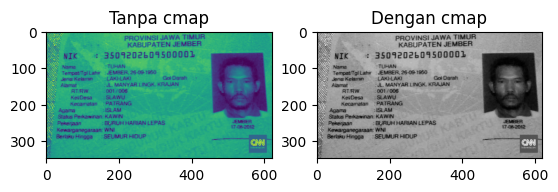

In [7]:
img_gray = cv.imread('KTP TUHAN.jpeg', cv.IMREAD_GRAYSCALE)

#tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

#dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

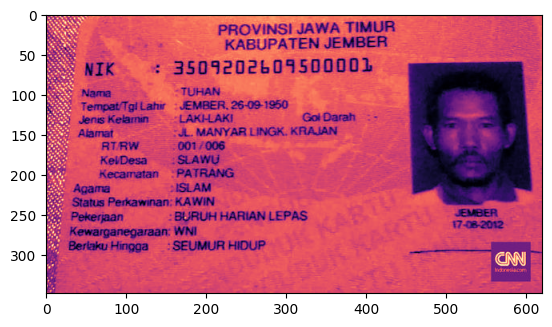

In [8]:
plt.imshow(img_gray, cmap='magma')

4. Melakukan resizing

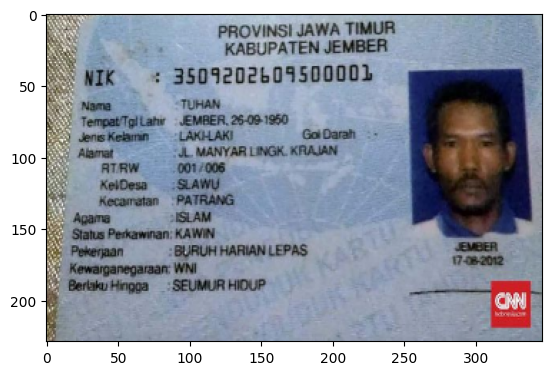

In [9]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

5. Melakukan Flipping

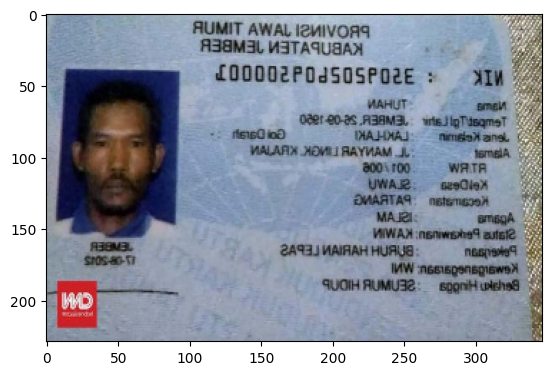

In [10]:
imgFlip = cv.flip(img_output,1)
plt.imshow(imgFlip)

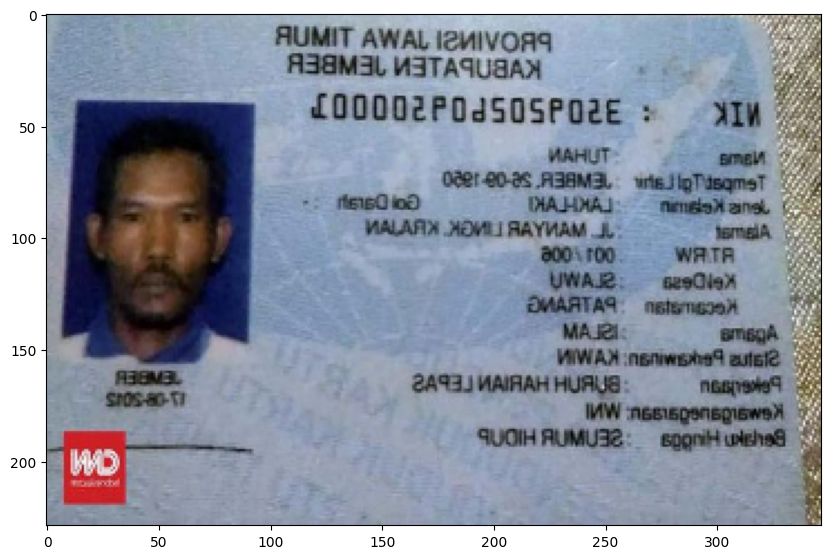

In [11]:
imgFlip = cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16

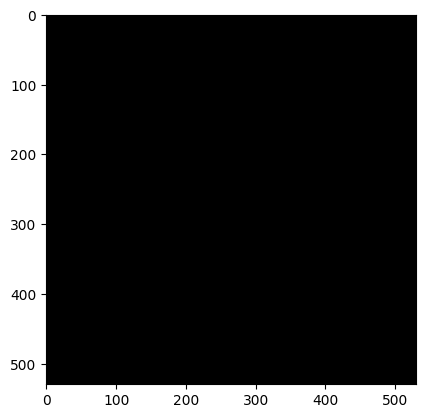

In [12]:
black_img = np.zeros((530,530,3), dtype=np.int16)
plt.imshow(black_img)

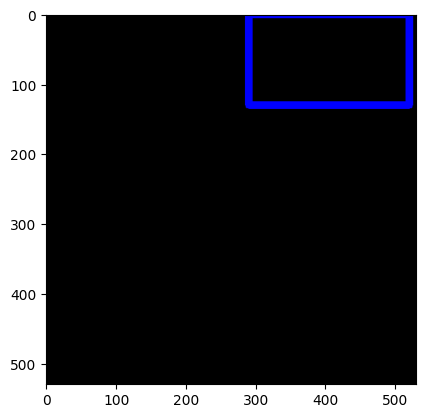

In [13]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

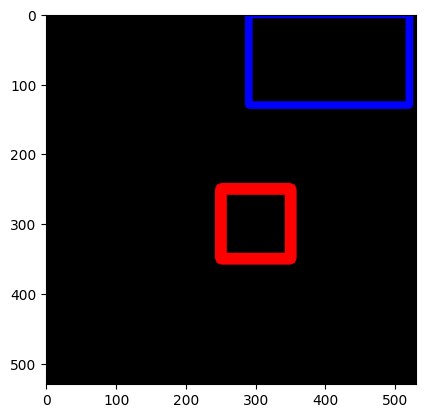

In [14]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

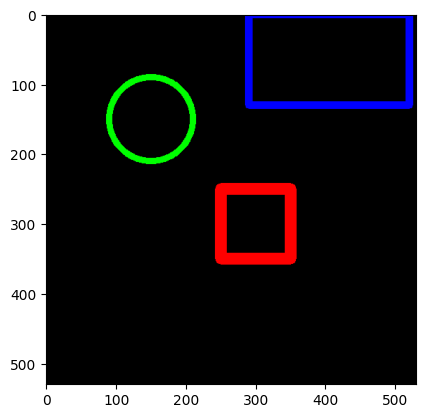

In [15]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

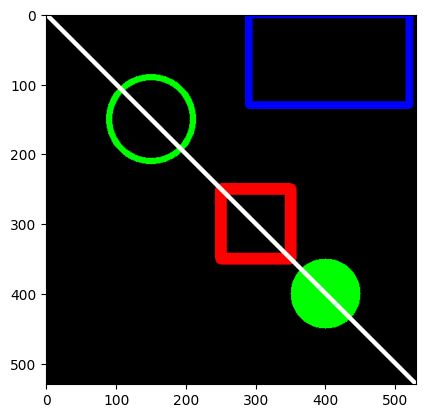

In [16]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

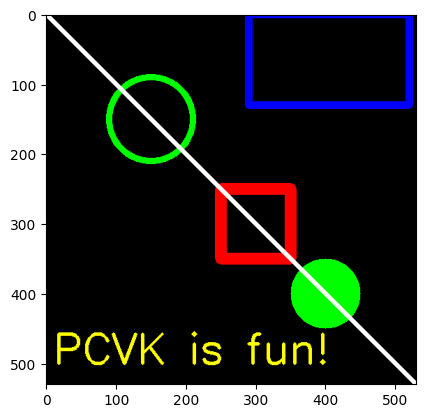

In [17]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,
           color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

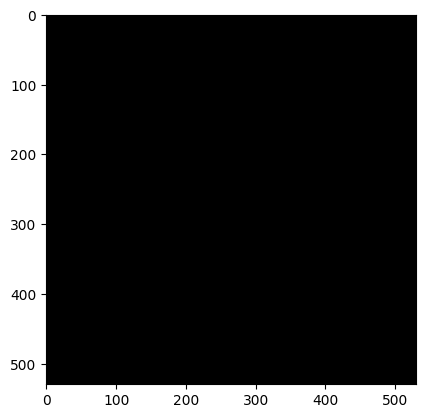

In [18]:
black_img2 = np.zeros((530,530,3), dtype=np.int32)
plt.imshow(black_img2)

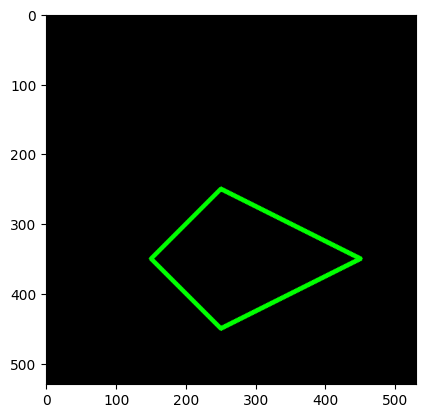

In [19]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
pts = vertices.reshape((-1,1,2)) #nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yang mewakili R, G, dan B
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

#PERTANYAAN PRAKTIKUM

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

    Jawab : Karena OpenCV membaca citra dalam format warna BGR (Blue, Green, Red), sedangkan Matplotlib membaca citra dalam format RGB (Red, Green, Blue)

Tampilan cv2_imshow():


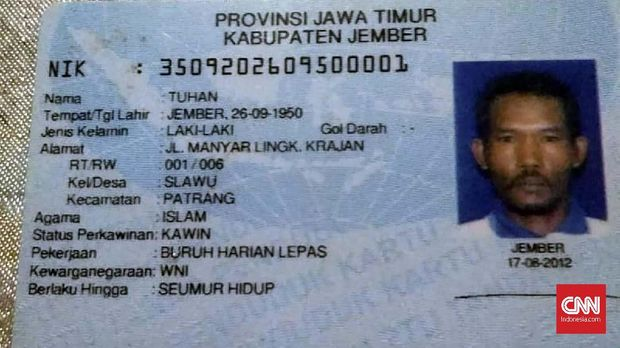

Tampilan plt.imshow():


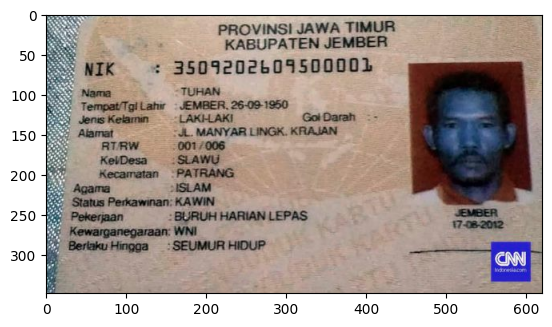

In [22]:
img = cv2.imread('KTP TUHAN.jpeg')

print("Tampilan cv2_imshow():")
cv2_imshow(img)

print("Tampilan plt.imshow():")
plt.imshow(img)
plt.show()

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

    Jawab : Ya, berbeda. Karena tipe data int16 menggunakan 16bit (2 byte) per piksel, sedangkan int32 menggunakan 32bit (4 byte) per piksel. Sehingga nbytes dari int32 tepat dua kali lebih besar daripada int16

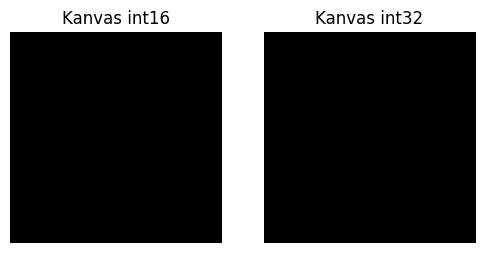

--- Hasil Perbandingan Properti ---
int16 -> dtype: int16 | min: 0 | max: 0 | nbytes: 80000 bytes
int32 -> dtype: int32 | min: 0 | max: 0 | nbytes: 160000 bytes


In [27]:
import numpy as np

#buat kanvas hitam berukuran sama
img_int16 = np.zeros((200, 200), dtype=np.int16)
img_int32 = np.zeros((200, 200), dtype=np.int32)

#menampilkan berdampingan menggunakan Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_int16, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Kanvas int16")
axes[0].axis('off')

axes[1].imshow(img_int32, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Kanvas int32")
axes[1].axis('off')
plt.show()

#cetak perbandingan nilai
print("--- Hasil Perbandingan Properti ---")
print("int16 -> dtype:", img_int16.dtype, "| min:", img_int16.min(), "| max:", img_int16.max(), "| nbytes:", img_int16.nbytes, "bytes")
print("int32 -> dtype:", img_int32.dtype, "| min:", img_int32.min(), "| max:", img_int32.max(), "| nbytes:", img_int32.nbytes, "bytes")

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?

    Jawab : cv2_imshow merupakan fungsi pengganti bawaan dari Google Colab untuk cv2.imshow milik OpenCV yang dimana fungsinya untuk merender citra agar tampil langsung di dalam notebook. Dan cv2.imshow() milik OpenCV tidak dapat dipakai di Google Colab karena Google colab berjalan di server dan tidak memiliki GUI/layar monitor, sehingga membutuhkan cv_imshow untuk menampilkannya

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.

    Jawab : skimage.io.imread() membaca citra langsung kedalam format RGB. Sedangkan cv2.imread() membaca citra dalam BGR, namun jika ditambahkan cv2.cvtColor(img, cv2.COLOR_BGR2RGB), maka urutan warna dikembalikan menjadi RGB.

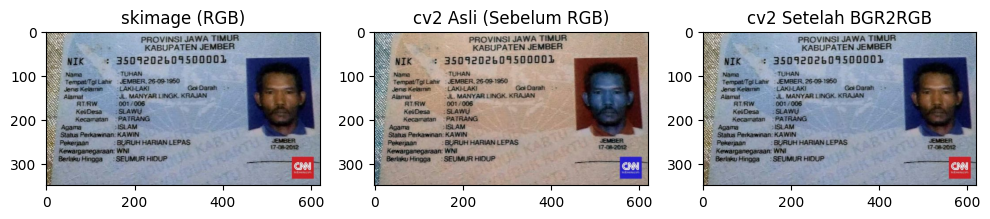

Nilai piksel skimage (RGB) : [129 127 106]
Nilai piksel cv2 (BGR)     : [106 127 129]
Nilai piksel cv2 (RGB)     : [129 127 106]


In [8]:
import cv2
import matplotlib.pyplot as plt
from skimage import io

path = 'KTP TUHAN.jpeg'

#baca gambar
img_skimage = io.imread(path) #format RGB
img_cv2_bgr = cv2.imread(path) #format BGR
img_cv2_rgb = cv2.cvtColor(img_cv2_bgr, cv2.COLOR_BGR2RGB) #format BGR -> RGB

#menampilkan 3 gambar berdampingan
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_skimage)
axes[0].set_title("skimage (RGB)")

axes[1].imshow(img_cv2_bgr)
axes[1].set_title("cv2 Asli (Sebelum RGB)")

axes[2].imshow(img_cv2_rgb)
axes[2].set_title("cv2 Setelah BGR2RGB")

plt.show()

#bukti nilai piksel
print("Nilai piksel skimage (RGB) :", img_skimage[0, 0])
print("Nilai piksel cv2 (BGR)     :", img_cv2_bgr[0, 0])
print("Nilai piksel cv2 (RGB)     :", img_cv2_rgb[0, 0])

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.

    Jawab : figsize hanya mengatur besar kecilnya gambar yang digambar pada layar notebook sehingga tidak merubah nilai img.shape. Sedangkan cv2.resize() memproses ulang data gambar dengan cara menambah atau memotong baris dan kolom pikselnya

#TUGAS PRAKTIKUM - Penerapan

1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-
Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya
berdampingan dalam satu figure yang diberi judul.

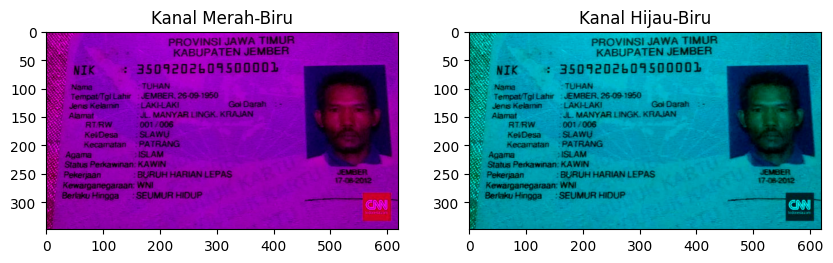

In [11]:
import cv2
import matplotlib.pyplot as plt

#baca gambar
img_bgr = cv2.imread('KTP TUHAN.jpeg')

#buat kombinasi warna
#kombinasi Merah-Biru
rb_img = img_rgb.copy()
rb_img[:, :, 1] = 0

#kombinasi Hijau-Biru
gb_img = img_rgb.copy()
gb_img[:, :, 0] = 0

#menampilkan berdampingan dalam satu figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(rb_img)
axes[0].set_title("Kanal Merah-Biru")

axes[1].imshow(gb_img)
axes[1].set_title("Kanal Hijau-Biru")

plt.show()

2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan
keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi
label.

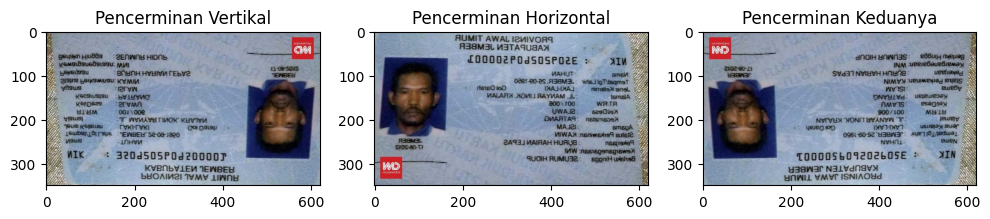

In [12]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread('KTP TUHAN.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

#proses pencerminan menggunakan cv2.flip()
#flipCode: 0 = Vertikal, 1 = Horizontal, -1 = Keduanya (Vertikal & Horizontal)
flip_v = cv2.flip(img_rgb, 0)
flip_h = cv2.flip(img_rgb, 1)
flip_vh = cv2.flip(img_rgb, -1)

#menampilkan dalam satu figure
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(flip_v)
axes[0].set_title("Pencerminan Vertikal")

axes[1].imshow(flip_h)
axes[1].set_title("Pencerminan Horizontal")

axes[2].imshow(flip_vh)
axes[2].set_title("Pencerminan Keduanya")

plt.show()

3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah /
badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan
teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda
tentukan sendiri.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving STD14897.JPG to STD14897.JPG


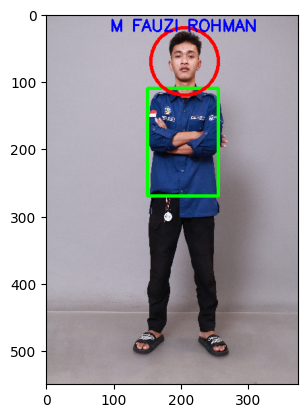

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("STD14897.JPG")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (375, 550)) #ukuran disamakan dengan contoh

#kotak hijau di area badan
cv2.rectangle(
    img,
    (150, 110), #koordinat sudut kiri-bawah (x, y)
    (255, 270), #koordinat sudut kanan-atas (x, y)
    (0, 255, 0), #warna hijau
    3
)

#lingkaran merah di area kepala
cv2.circle(
    img,
    (205, 70),  #titik pusat lingkaran (x, y)
    50,         #jari-jari (radius)
    (255, 0, 0), #warna merah
    3
)

#text nama
cv2.putText(
    img,
    "M FAUZI ROHMAN",
    (95, 25),  #posisi teks (x, y)
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,        #ukuran font
    (0, 0, 255), #warna biru
    2
)
plt.imshow(img)
plt.show()

#TUGAS PRAKTIKUM - Analisa

1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

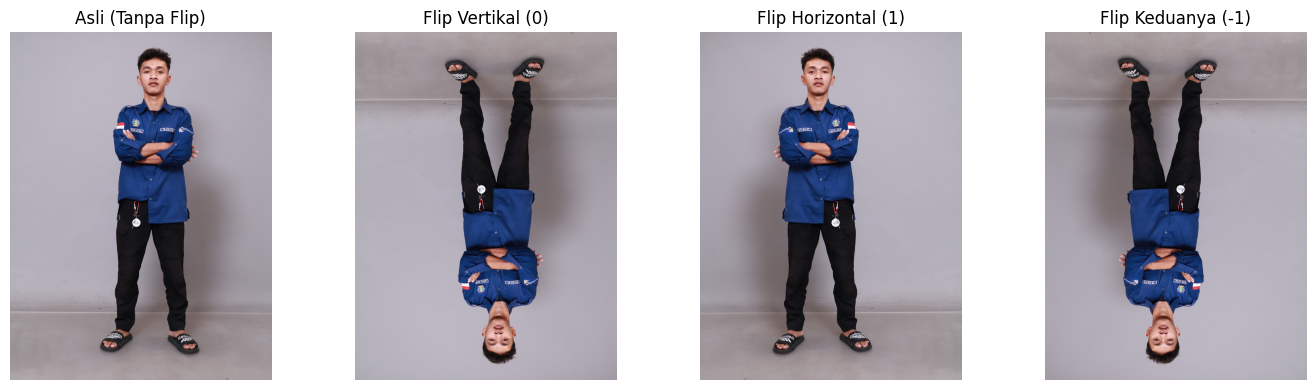

Dimensi Citra (Tinggi x Lebar) : 5328 x 4000 piksel
--------------------------------------------------
Piksel Pojok Kiri-Atas (0,0) Asli     : [170 169 177]
Piksel Pojok Kiri-Atas (0,0) Flip Horiz: [162 156 166]
Piksel Pojok Kanan-Atas Asli (0, w-1) : [162 156 166]


In [8]:
import cv2
import matplotlib.pyplot as plt

#baca gambar & konversi ke RGB
path = "STD14897.JPG"
img_bgr = cv2.imread(path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

#proses Pencerminan (Flip)
flip_v = cv2.flip(img_rgb, 0) #vertikal (atas-bawah)
flip_h = cv2.flip(img_rgb, 1) #horizontal (kiri-kanan)
flip_vh = cv2.flip(img_rgb, -1) #keduanya (vertikal & horizontal)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Asli (Tanpa Flip)")
axes[0].axis('off')

axes[1].imshow(flip_v)
axes[1].set_title("Flip Vertikal (0)")
axes[1].axis('off')

axes[2].imshow(flip_h)
axes[2].set_title("Flip Horizontal (1)")
axes[2].axis('off')

axes[3].imshow(flip_vh)
axes[3].set_title("Flip Keduanya (-1)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

h, w, _ = img_rgb.shape
print(f"Dimensi Citra (Tinggi x Lebar) : {h} x {w} piksel")
print("--------------------------------------------------")
print("Piksel Pojok Kiri-Atas (0,0) Asli     :", img_rgb[0, 0])
print("Piksel Pojok Kiri-Atas (0,0) Flip Horiz:", flip_h[0, 0])
print("Piksel Pojok Kanan-Atas Asli (0, w-1) :", img_rgb[0, w-1])

#TUGAS PRAKTIKUM - Aplikasi

Studi Kasus 1: Panitia sebuah kegiatan perlu membubuhkan label identitas pada
ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel,
sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada
semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua
citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama. Silakan melakukan akuisisi data sendiri, setiap anak
harus menggunakan image yang berbeda-beda

In [20]:
from google.colab import files
uploaded = files.upload()

Saving sawah.jpg to sawah.jpg


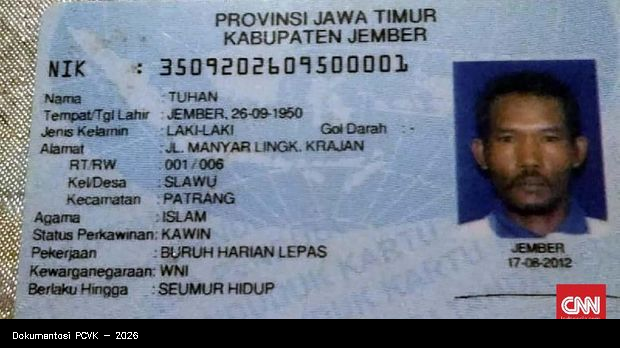

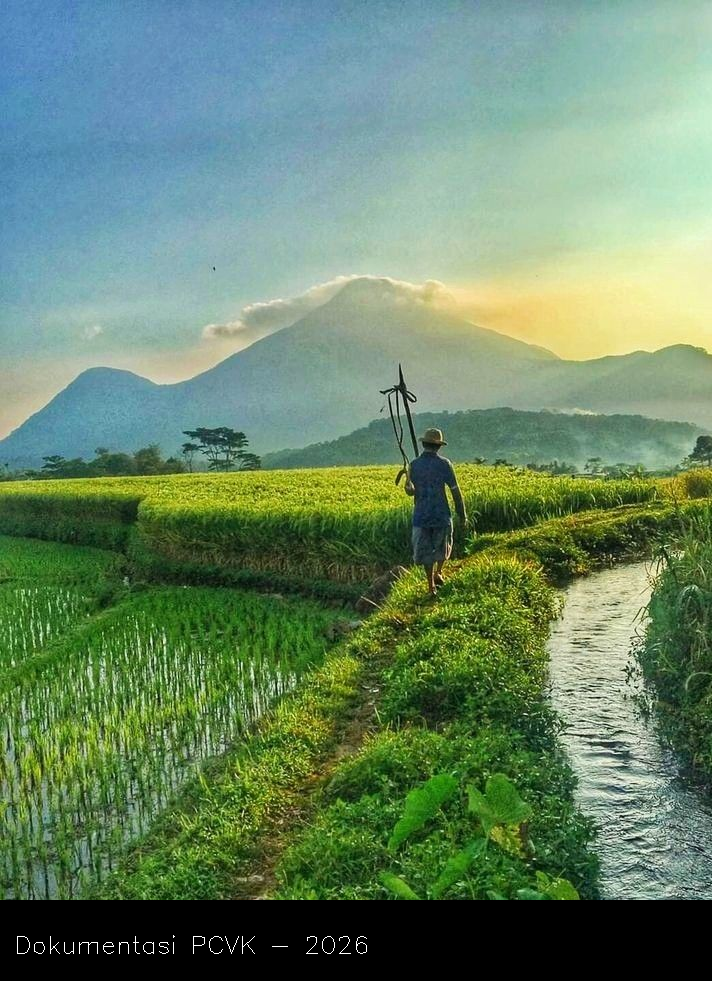

In [22]:
import cv2
from google.colab.patches import cv2_imshow

foto1 = cv2.imread("KTP TUHAN.jpeg")
foto2 = cv2.imread("sawah.jpg")

def tambah_label(img_label):
    h, w = img_label.shape[:2]

    #tinggi bar = 1/12 dari tinggi gambar
    tinggi_bar = int(h / 12)

    #tulisan menyesuaikan ukuran gambar
    ukuran_huruf = h / 1200
    ketebalan = max(1, int(h / 500))

    #membuat bar hitam di bagian bawah
    cv2.rectangle(img_label,
                  (0, h - tinggi_bar),
                  (w, h),
                  (0, 0, 0),
                  -1)

    #menambahkan label
    cv2.putText(img_label,
                "Dokumentasi PCVK - 2026",
                (int(w * 0.02), h - int(tinggi_bar * 0.35)),
                cv2.FONT_HERSHEY_SIMPLEX,
                ukuran_huruf,
                (255, 255, 255),
                ketebalan)

    return img_label

hasil1 = tambah_label(foto1)
hasil2 = tambah_label(foto2)

cv2_imshow(hasil1)
cv2_imshow(hasil2)